# CAVS: Cycle Microtrips

This Connected Automated Vehicle (CAV) demo extracts and plots individual
microtrips from a drive cycle.

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

sys.path.insert(0, str(next(p / "demo_scripts" for p in (Path.cwd(), *Path.cwd().parents) if (p / "demo_scripts").is_dir())))

import fastsim as fsim
from plot_utils import BASE_COLORS, BASE_LINE_STYLES

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Extract Microtrips

`Cycle.to_microtrips` splits a drive cycle into individual microtrips.
An optional `stop_speed` parameter sets the threshold below which the
vehicle is considered stopped.

In [3]:
cycle = fsim.Cycle.from_resource("udds.csv")
microtrips = cycle.to_microtrips(None)

The first four microtrips from the Urban Dynamometer Driving Schedule
(UDDS) cycle.

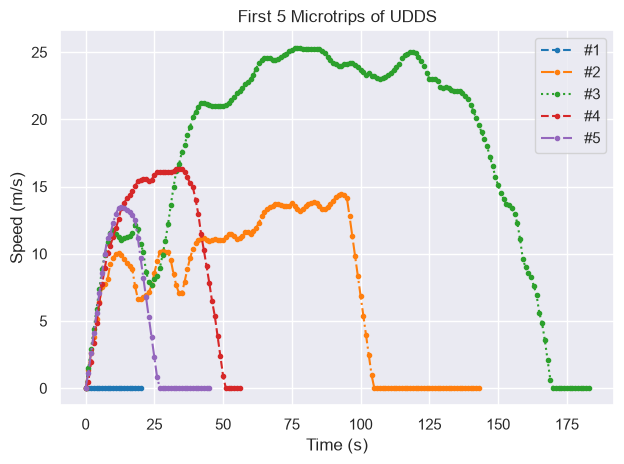

In [4]:
if SHOW_PLOTS:
    max_microtrips = 4
    fig, ax = plt.subplots()
    num = min(max_microtrips, len(microtrips))
    for idx, mt in enumerate(microtrips):
        mtd = mt.to_pydict()
        color = BASE_COLORS[idx % len(BASE_COLORS)]
        line = BASE_LINE_STYLES[idx % len(BASE_LINE_STYLES)]
        ax.plot(
            mtd["time_seconds"],
            mtd["speed_meters_per_second"],
            marker=".",
            color=color,
            linestyle=line,
            label=f"#{idx + 1}",
        )
        if idx >= max_microtrips:
            break
    ax.set_title(f"First {num + 1} Microtrips of UDDS")
    ax.set_ylabel("Speed (m/s)")
    ax.set_xlabel("Time (s)")
    ax.legend()
    fig.tight_layout()
    if SAVE_FIGS:
        plt.savefig(Path("./plots/microtrips.svg"))
    plt.show()